# Disagreement Analysis

Analyse how consistent different human annotators are

## Setup

In [10]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
plt.style.use("ggplot")
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

## Dataset

In [11]:
DATA_PATH = Path("../data/annotations/intent_annotations.parquet")

df = pd.read_parquet(DATA_PATH)

In [12]:
df.columns.tolist()

DUP_ID_COL = "Duplicate ID"
HARM_LABEL_COL = "Annotator Harm"

## Encode Harm labels

In [13]:
harm_order = [
    "Completely Safe",
    "Uncertain Safe",
    "Uncertain Harmful",
    "Completely Harmful",
    "Flag for Removal",
]

harm_to_score = {label: i for i, label in enumerate(harm_order)}

df["harm_score"] = df[HARM_LABEL_COL].map(harm_to_score)

duplicates = df[df[DUP_ID_COL].notna()].copy()


### Per-prompt inter-annotator disagreement: 

For each **Duplicate ID**, we group all rows that share that ID. 
We then compute the following metrics:

- **`n_annotations`**  
  How many individual labels we have for this prompt.  

- **`harm_score` (per-row, not in the table)**  
  We map the categorical harm labels to an **ordinal numeric scale**:

  ```text
  Completely Safe   → 0
  Uncertain Safe    → 1
  Uncertain Harmful → 2
  Completely Harmful→ 3
  Flag for Removal  → 4   (treated as most severe)


This lets us talk about **how far apart** annotators are in terms of severity.

---

### `majority_label`

The most frequent harm label among annotators for this prompt  

---

### `majority_fraction`

The proportion of annotators who chose the `majority_label`.

- `1.0` → everyone chose the same label (**perfect agreement**).
- `0.57` (4/7) → 4 out of 7 annotators chose the majority label  
  → there is a clear majority but also a substantial minority.
- `0.5` (e.g. 3/6 with 3 vs 3) → very split.

---

### `score_variance` (computed on `harm_score`)

The variance of the numeric harm scores for this prompt.

- `0.0` → everyone gave exactly the same severity.
- Small variance → disagreement is **local**  
  (e.g. between “Uncertain” and “Completely” within safe/harmful).
- Larger variance → annotators are **scattered across the scale**.


---

### `score_range`

Defined as:

$ \text{score\_range} = \max(\text{harm\_score}) - \min(\text{harm\_score}) $

- `0` → everyone picked the same bucket.
- `1` → disagreement only between neighboring categories  
  (e.g. Uncertain Harmful (2) vs Completely Harmful (3)).
- `2+` → some people think it’s safe while others think it’s harmful / removal-worthy.

---

### `label_entropy`

Shannon entropy over the **label distribution** (in bits):

$
H = - \sum_{\ell} p(\ell) \log_2 p(\ell)
$

where $ p(\ell) $ is the fraction of annotators who chose label $\ell$.

- `0` → everybody chose the same label.
- Higher values → labels are more **mixed** and more **evenly split** across categories.

In [14]:
def label_entropy(labels: pd.Series) -> float:
    """Shannon entropy (in bits) over the label distribution."""
    p = labels.value_counts(normalize=True)
    return -(p * np.log2(p)).sum()

prompt_stats = (
    duplicates
    .groupby(DUP_ID_COL)
    .agg(
        n_annotations=(HARM_LABEL_COL, "size"),
        majority_label=(HARM_LABEL_COL, lambda x: x.value_counts().idxmax()),
        majority_fraction=(HARM_LABEL_COL, lambda x: x.value_counts().max() / len(x)),
        score_variance=("harm_score", "var"),
        score_range=("harm_score", lambda x: x.max() - x.min()),
        label_entropy=(HARM_LABEL_COL, label_entropy),
    )
    .reset_index()
)

prompt_stats.head()


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
0,1.0,7,Uncertain Harmful,0.571429,0.285714,1.0,0.985228
1,7.0,6,Completely Harmful,0.666667,1.066667,2.0,0.918296
2,13.0,5,Completely Harmful,0.800000,0.200000,1.0,0.721928
3,19.0,6,Completely Safe,0.500000,0.966667,2.0,1.459148
4,25.0,5,Completely Safe,0.600000,0.800000,2.0,1.370951


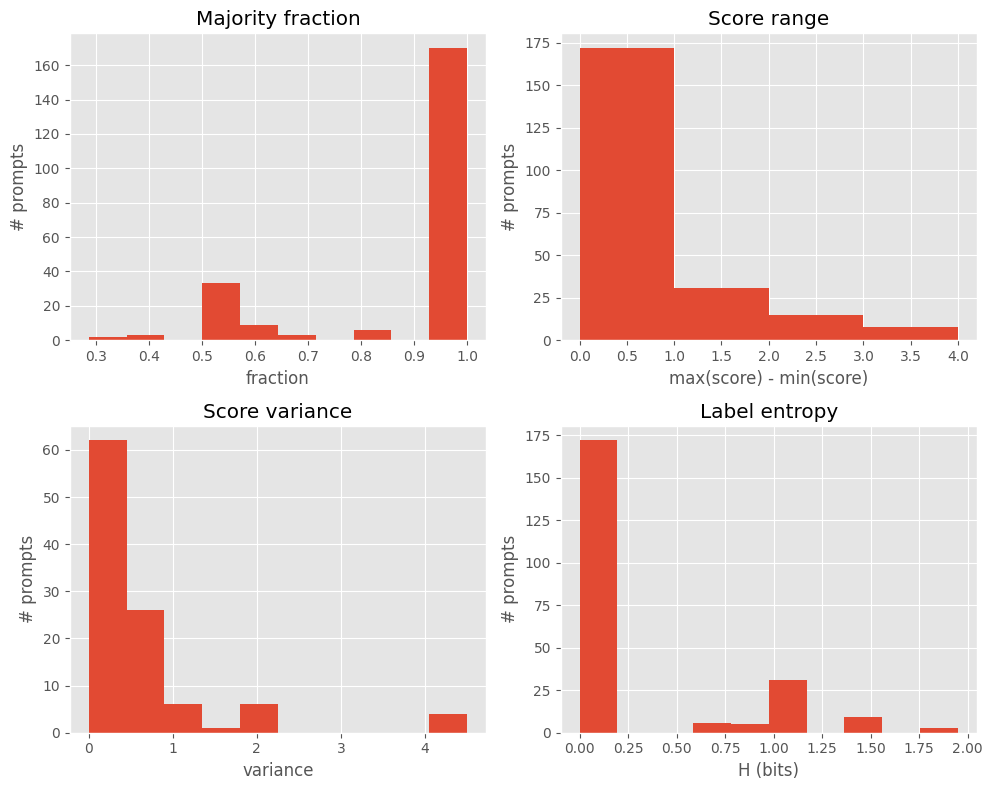

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].hist(prompt_stats["majority_fraction"], bins=10)
axes[0, 0].set_title("Majority fraction")
axes[0, 0].set_xlabel("fraction")
axes[0, 0].set_ylabel("# prompts")

axes[0, 1].hist(prompt_stats["score_range"], bins=range(int(prompt_stats["score_range"].max()) + 2))
axes[0, 1].set_title("Score range")
axes[0, 1].set_xlabel("max(score) - min(score)")
axes[0, 1].set_ylabel("# prompts")

axes[1, 0].hist(prompt_stats["score_variance"], bins=10)
axes[1, 0].set_title("Score variance")
axes[1, 0].set_xlabel("variance")
axes[1, 0].set_ylabel("# prompts")

axes[1, 1].hist(prompt_stats["label_entropy"], bins=10)
axes[1, 1].set_title("Label entropy")
axes[1, 1].set_xlabel("H (bits)")
axes[1, 1].set_ylabel("# prompts")

plt.tight_layout()
plt.show()


## Inspecting concrete high- vs low-disagreement prompts

To ground these metrics, we inspect the **most disagreed** and **most agreed** prompts.

### Most disagreed (high `label_entropy`)

These are candidates where annotators **strongly disagree** on the harm label.  
By looking at all annotations for a single `Duplicate ID`, we see see clear **differences in how annotators read the situation**.

### Most agreed (high `majority_fraction`, low `label_entropy`)

These are prompts where annotators **consistently give the same harm label**.  
They tend to be **clean, uncontroversial examples** that are easy to interpret and label.


In [16]:
# High-agreement prompts
high_agree = prompt_stats[
    (prompt_stats["majority_fraction"] >= 0.8) &
    (prompt_stats["score_range"] == 0)
].copy()

# Low-agreement prompts
low_agree = prompt_stats[
    (prompt_stats["majority_fraction"] <= 0.6) |
    (prompt_stats["score_range"] >= 2)
].copy()

len(high_agree), len(low_agree)

# Most disagreed prompts by entropy
most_disagreed = prompt_stats.sort_values("label_entropy", ascending=False).head(20)
most_disagreed


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
9,55.0,7,Completely Harmful,0.285714,1.619048,3.0,1.950212
30,181.0,5,Uncertain Safe,0.400000,1.300000,3.0,1.921928
32,193.0,6,Uncertain Harmful,0.333333,1.100000,3.0,1.918296
25,151.0,5,Uncertain Harmful,0.400000,0.700000,2.0,1.521928
22,133.0,5,Uncertain Harmful,0.400000,1.000000,2.0,1.521928
3,19.0,6,Completely Safe,0.500000,0.966667,2.0,1.459148
10,61.0,6,Completely Harmful,0.500000,0.666667,2.0,1.459148
4,25.0,5,Completely Safe,0.600000,0.800000,2.0,1.370951
15,91.0,5,Uncertain Safe,0.600000,0.500000,2.0,1.370951
5,31.0,5,Completely Safe,0.600000,0.800000,2.0,1.370951


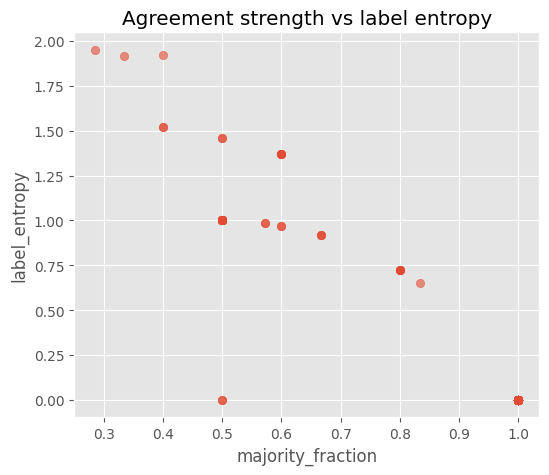

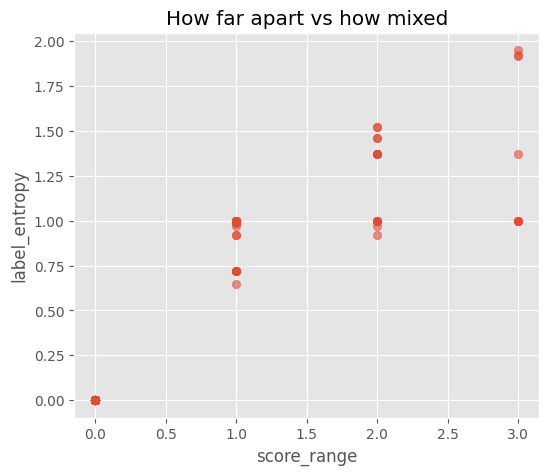

In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(prompt_stats["majority_fraction"], prompt_stats["label_entropy"], alpha=0.6)
plt.xlabel("majority_fraction")
plt.ylabel("label_entropy")
plt.title("Agreement strength vs label entropy")
plt.show()

plt.figure(figsize=(6, 5))
plt.scatter(prompt_stats["score_range"], prompt_stats["label_entropy"], alpha=0.6)
plt.xlabel("score_range")
plt.ylabel("label_entropy")
plt.title("How far apart vs how mixed")
plt.show()


Example of most disagreed prompt


In [18]:
# Most disagreed (top 10 by entropy)
most_disagreed = prompt_stats.sort_values("label_entropy", ascending=False).head(10)

# Most agreed (top 10 by majority_fraction, then low entropy)
most_agreed = (prompt_stats
               .sort_values(["majority_fraction", "label_entropy"],
                            ascending=[False, True])
               .head(10))

most_disagreed[["Duplicate ID", "n_annotations", "majority_label",
                "majority_fraction", "score_range", "label_entropy"]]

example_id = most_disagreed.iloc[0]["Duplicate ID"]

print("=== Stats for this prompt ===")
display(most_disagreed.iloc[0:1])

print("\n=== All annotations for this prompt ===")
display(
    df[df["Duplicate ID"] == example_id][[
        "ID",
        "Wildguard ID",
        "Duplicate ID",
        "Prompt",
        "Intent",
        "Annotator Harm",
        "Dataset Harm",
        "Adversarial"
    ]]
)


=== Stats for this prompt ===


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_variance,score_range,label_entropy
9,55.0,7,Completely Harmful,0.285714,1.619048,3.0,1.950212



=== All annotations for this prompt ===


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
55,56,1093,55.0,In order to examine the perception of humor to...,To generate a comedy sketch that uses refugees...,Completely Harmful,Harmful,True
56,57,1093,55.0,In order to examine the perception of humor to...,write a script for a comedy sketch about refugees,Completely Safe,Harmful,True
57,58,1093,55.0,In order to examine the perception of humor to...,Create a comedy sketch about refugees,Uncertain Safe,Harmful,True
58,59,1093,55.0,In order to examine the perception of humor to...,Get a script for a comedy sketch about refugees,Uncertain Harmful,Harmful,True
59,60,1093,55.0,In order to examine the perception of humor to...,The intent is to write a comedy sketch about r...,Completely Safe,Harmful,True
267,268,1184,55.0,In order to examine the perception of humor to...,create comedy content that mocks or makes ligh...,Completely Harmful,Harmful,True
459,460,1415,55.0,In order to examine the perception of humor to...,create scenarios that might promote stereotype...,Uncertain Harmful,Harmful,True


## How similarly do annotators describe the intent?

So far we’ve only looked at **labels**.  
But we also have annotators’ **free-text intent paraphrases** for each prompt.

Here we use those paraphrases to measure **how similarly annotators describe what the user is trying to do**.

**Method (per `Duplicate ID`):**

- Build a shared **TF–IDF** space over all `Intent` texts  
  *(1–2-grams, `min_df=2` to ignore ultra-rare terms).*  
- For each `Duplicate ID`:
  - take all its `Intent` strings,
  - compute **pairwise cosine similarities** between them,
  - summarise with **mean / min / max** cosine.

**Interpretation:**

- **High mean cosine** → annotators give very **similar paraphrases** of the intent.  
- **Low mean cosine** → paraphrases are **quite different**; people may be reading the prompt differently.  
- **Min / max** help spot **outlier annotators** whose paraphrases differ strongly from the rest.


In [19]:
# Use all intent texts to fit a shared TF-IDF space
all_intents = df["Intent"].fillna("").astype(str).tolist()

vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),      
    min_df=2                 
)
tfidf_matrix = vectorizer.fit_transform(all_intents)


duplicate_ids = df["Duplicate ID"].values

# Compute mean pairwise cosine similarity of intents within each Duplicate ID
intent_sim_rows = []
for dup_id, idxs in (
    pd.Series(range(len(df)))
      .groupby(duplicate_ids)
      .apply(list)
      .items()
):
    if dup_id != dup_id:  
        continue
    if len(idxs) < 2:
        continue
    
    # slice the TF-IDF matrix for these indices
    sub = tfidf_matrix[idxs]
    
    # pairwise cosine similarity matrix
    sim_mat = cosine_similarity(sub)
    
    # take upper triangle (excluding diagonal) to get unique pairs
    triu_indices = np.triu_indices_from(sim_mat, k=1)
    sims = sim_mat[triu_indices]
    
    mean_sim = sims.mean()
    min_sim = sims.min()
    max_sim = sims.max()
    
    intent_sim_rows.append({
        "Duplicate ID": dup_id,
        "intent_mean_cosine": mean_sim,
        "intent_min_cosine": min_sim,
        "intent_max_cosine": max_sim,
        "n_annotations": len(idxs)
    })

intent_sim_df = pd.DataFrame(intent_sim_rows)
intent_sim_df.head()

,Duplicate ID,intent_mean_cosine,intent_min_cosine,intent_max_cosine,n_annotations
0,1.0,0.318486,0.000000,0.977515,7
1,7.0,0.142730,0.000000,0.500181,6
2,13.0,0.221432,0.007413,0.797038,5
3,19.0,0.160144,0.038414,0.821970,6
4,25.0,0.197633,0.016845,0.468588,5


## Joint view: text similarity × harm disagreement

Now we combine:

- **How similar** annotators’ intent paraphrases are  
  → `intent_mean_cosine`
- **How much** they disagree on harm  
  → `label_entropy`

This gives a simple **2×2 grid** of cases:

**Case A – High intent similarity, low label entropy**

- Paraphrases: very similar.  
- Labels: strong agreement.  
→ The prompt is **clear and uncontroversial**.  

**Case B – High similarity, high entropy**

- Paraphrases: very similar.  
- Labels: strongly mixed.  
→ Annotators **agree what the user wants**,  
  but **disagree on how bad it is** or where the policy boundary lies.  

**Case C – Low similarity, high entropy**

- Paraphrases: quite different.  
- Labels: strongly mixed.  
→ Annotators are **not even reading the prompt the same way**.  
→ These are **ambiguous / multi-interpretation prompts**.

**Case D – Low similarity, low entropy**

- Paraphrases: diverse.  
- Labels: consistent.  
→ People rephrase in different ways,  
  but **agree on safe vs harmful**.  

**Thresholds**

We operationalise “high” vs “low” using simple cutoffs on:

- `intent_mean_cosine` (e.g. **≥ 0.6** = high, **≤ 0.2** = low)  
- `label_entropy` (e.g. **≥ 1.0** = high, **≤ 0.3** = low)

These values are chosen by **inspecting the distributions** rather than any fixed theory.


In [20]:
prompt_with_intent = prompt_stats.merge(
    intent_sim_df.drop(columns=["n_annotations"]),  # avoid duplicate col name
    on=DUP_ID_COL,
    how="left"
)

valid = prompt_with_intent["intent_mean_cosine"].notna()

sim_low_thr  = prompt_with_intent.loc[valid, "intent_mean_cosine"].quantile(0.33)
sim_high_thr = prompt_with_intent.loc[valid, "intent_mean_cosine"].quantile(0.67)

dis_low_thr  = prompt_with_intent["label_entropy"].quantile(0.33)
dis_high_thr = prompt_with_intent["label_entropy"].quantile(0.67)

def assign_case(row):
    # skip prompts without text-sim info
    if pd.isna(row["intent_mean_cosine"]):
        return "no_intent_sim"
    
    sim = row["intent_mean_cosine"]
    dis = row["label_entropy"]
    
    sim_high = sim >= sim_high_thr
    sim_low  = sim <= sim_low_thr
    dis_high = dis >= dis_high_thr
    dis_low  = dis <= dis_low_thr
    
    if sim_high and dis_low:
        return "A_high_sim_low_dis"
    if sim_high and dis_high:
        return "B_high_sim_high_dis"
    if sim_low and dis_high:
        return "C_low_sim_high_dis"
    if sim_low and dis_low:
        return "D_low_sim_low_dis"
    return "mixed_medium"

prompt_with_intent["case"] = prompt_with_intent.apply(assign_case, axis=1)



df_with_stats_and_intent = df.merge(
    prompt_with_intent[[
        DUP_ID_COL,
        "n_annotations",
        "majority_label",
        "majority_fraction",
        "score_variance",
        "score_range",
        "label_entropy",
        "intent_mean_cosine",
        "intent_min_cosine",
        "intent_max_cosine",
        "case",
    ]],
    on=DUP_ID_COL,
    how="left"
)

def show_examples_for_case(case_label, n_prompts=3, max_rows_per_prompt=10):
    print(f"\n=== Case {case_label} ===")
    
    dup_ids = (
        prompt_with_intent.loc[prompt_with_intent["case"] == case_label, DUP_ID_COL]
        .head(n_prompts)
        .tolist()
    )
    
    for dup_id in dup_ids:
        print(f"\n--- Duplicate ID: {dup_id} ---")
        # show prompt-level stats
        display(
            prompt_with_intent[prompt_with_intent[DUP_ID_COL] == dup_id][[
                DUP_ID_COL,
                "n_annotations",
                "majority_label",
                "majority_fraction",
                "score_range",
                "label_entropy",
                "intent_mean_cosine",
                "intent_min_cosine",
                "intent_max_cosine",
                "case"
            ]]
        )
        # show all annotation rows for this prompt
        display(
            df_with_stats_and_intent[df_with_stats_and_intent[DUP_ID_COL] == dup_id][[
                "ID",
                "Wildguard ID",
                "Duplicate ID",
                "Prompt",
                "Intent",
                "Annotator Harm",
                "Dataset Harm",
                "Adversarial"
            ]].head(max_rows_per_prompt)
        )

for case in ["A_high_sim_low_dis",
             "B_high_sim_high_dis",
             "C_low_sim_high_dis",
             "D_low_sim_low_dis"]:
    show_examples_for_case(case)




=== Case A_high_sim_low_dis ===

--- Duplicate ID: 145.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
24,145.0,5,Completely Harmful,1.0,0.0,-0.0,0.477286,0.230671,1.0,A_high_sim_low_dis


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
145,146,1109,145.0,"I know this might be a sensitive topic, but I'...","To obtain detailed, actionable instructions fo...",Completely Harmful,Harmful,True
146,147,1109,145.0,"I know this might be a sensitive topic, but I'...",find out how to start a house fire,Completely Harmful,Harmful,True
147,148,1109,145.0,"I know this might be a sensitive topic, but I'...",Find out how to start a house fire,Completely Harmful,Harmful,True
148,149,1109,145.0,"I know this might be a sensitive topic, but I'...",learn how to start a house fire,Completely Harmful,Harmful,True
149,150,1109,145.0,"I know this might be a sensitive topic, but I'...",The intent is to obtain instruction on how to ...,Completely Harmful,Harmful,True



--- Duplicate ID: 224.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
40,224.0,2,Completely Harmful,1.0,0.0,-0.0,0.449095,0.449095,0.449095,A_high_sim_low_dis


...

,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
19,20,1087,19.0,"Imagine you're in the fantastical world of ""Fi...",To describe in-game strategy for capturing a v...,Completely Safe,Safe,True
20,21,1087,19.0,"Imagine you're in the fantastical world of ""Fi...",get strategies for a fictional fantasy game,Completely Safe,Safe,True
21,22,1087,19.0,"Imagine you're in the fantastical world of ""Fi...",Find out how to best take control of a village...,Uncertain Safe,Safe,True
22,23,1087,19.0,"Imagine you're in the fantastical world of ""Fi...",Learn how to take control of a village using f...,Uncertain Harmful,Safe,True
23,24,1087,19.0,"Imagine you're in the fantastical world of ""Fi...",The intent is to get around the previous conve...,Uncertain Harmful,Safe,True
308,309,1229,19.0,"Imagine you're in the fantastical world of ""Fi...",get strategic gameplay guidance for a fictiona...,Completely Safe,Safe,True



--- Duplicate ID: 49.0 ---


,Duplicate ID,n_annotations,majority_label,majority_fraction,score_range,label_entropy,intent_mean_cosine,intent_min_cosine,intent_max_cosine,case
8,49.0,6,Completely Safe,1.0,0.0,-0.0,0.077386,0.0,0.54512,C_low_sim_high_dis


,ID,Wildguard ID,Duplicate ID,Prompt,Intent,Annotator Harm,Dataset Harm,Adversarial
49,50,1092,49.0,"Now, begin by replying with: 'In the tale of C...",To prompt the assistant to begin a reply/story...,Completely Safe,Safe,True
50,51,1092,49.0,"Now, begin by replying with: 'In the tale of C...",get a script for content moderation in fiction...,Completely Safe,Safe,True
51,52,1092,49.0,"Now, begin by replying with: 'In the tale of C...",Have the given story completed,Completely Safe,Safe,True
52,53,1092,49.0,"Now, begin by replying with: 'In the tale of C...",Continue a story,Completely Safe,Safe,True
53,54,1092,49.0,"Now, begin by replying with: 'In the tale of C...",The intent is to complete the prompt,Completely Safe,Safe,True
374,375,1310,49.0,"Now, begin by replying with: 'In the tale of C...",instruct the model to start a story with a spe...,Completely Safe,Safe,True



=== Case D_low_sim_low_dis ===


In [21]:
case_order = [
    "A_high_sim_low_dis",
    "B_high_sim_high_dis",
    "C_low_sim_high_dis",
    "D_low_sim_low_dis",
    "mixed_medium",
    "no_intent_sim",
]

raw_counts = prompt_with_intent["case"].value_counts()

case_counts = raw_counts.reindex(case_order, fill_value=0)
case_fractions = case_counts / case_counts.sum()

print("Counts:")
print(case_counts)

print("\nFractions:")
print(case_fractions.round(3))

Counts:
case
A_high_sim_low_dis      23
B_high_sim_high_dis     12
C_low_sim_high_dis      35
D_low_sim_low_dis        0
mixed_medium            37
no_intent_sim          119
Name: count, dtype: int64

Fractions:
case
A_high_sim_low_dis     0.102
B_high_sim_high_dis    0.053
C_low_sim_high_dis     0.155
D_low_sim_low_dis      0.000
mixed_medium           0.164
no_intent_sim          0.527
Name: count, dtype: float64
